In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import zipfile
import os

with zipfile.ZipFile("engineered_data.zip", "r") as zip_ref:
    zip_ref.extractall("engineered")

print(os.listdir("engineered"))

['order_items_engineered.csv', 'orders_engineered.csv', 'products_engineered.csv', 'reviews_engineered.csv', 'customers_engineered.csv', 'sellers_engineered.csv']


In [ ]:
orders = pd.read_csv("../data/engineered/orders_engineered.csv")
customers = pd.read_csv("../data/engineered/customers_engineered.csv")
sellers = pd.read_csv("../data/engineered/sellers_engineered.csv")
products = pd.read_csv("../data/engineered/products_engineered.csv")
order_items = pd.read_csv("../data/engineered/order_items_engineered.csv")
reviews = pd.read_csv("../data/engineered/reviews_engineered.csv", engine="python")

print(orders.shape)
print(customers.shape)
print(sellers.shape)
print(products.shape)
print(order_items.shape)
print(reviews.shape)    

(99441, 16)
(99441, 9)
(3095, 6)
(32951, 13)
(112650, 7)
(99224, 7)


In [5]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

orders["order_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

orders[["order_id", "order_purchase_timestamp", "order_month"]].head()

,order_id,order_purchase_timestamp,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02


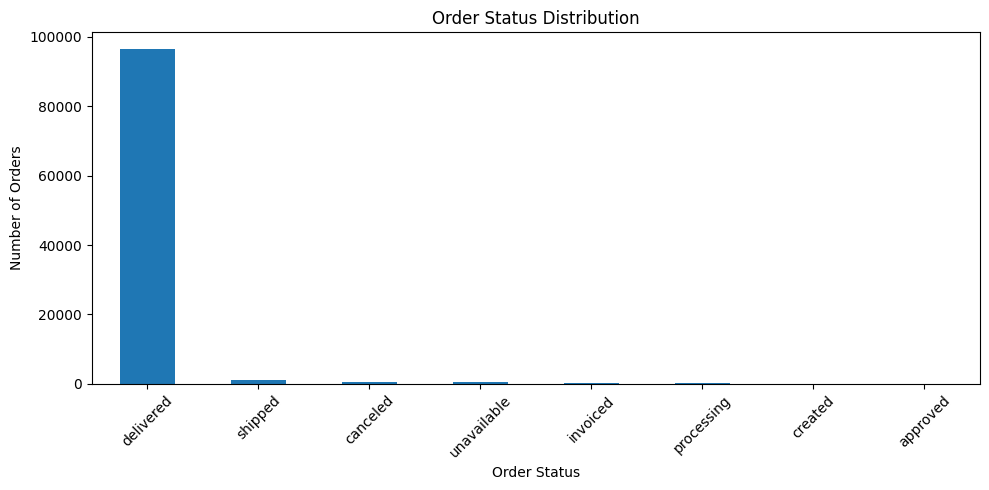

In [6]:
status_counts = orders["order_status"].value_counts()

plt.figure(figsize=(10, 5))
status_counts.plot(kind="bar")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

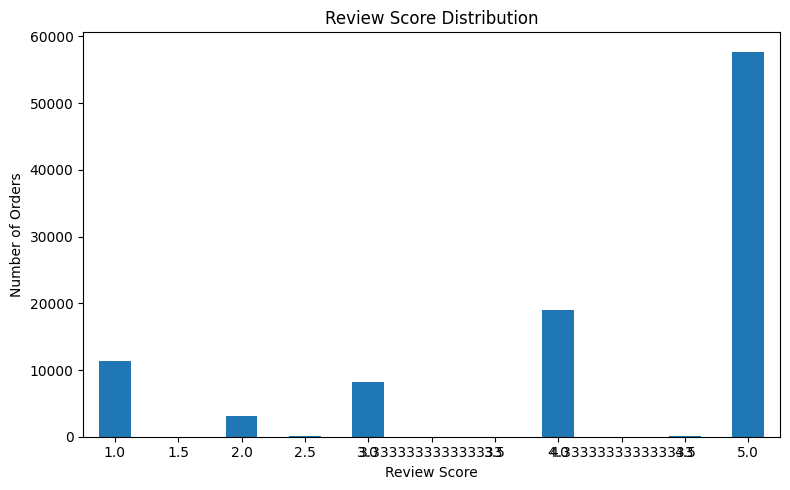

In [7]:
review_counts = orders["review_score"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
review_counts.plot(kind="bar")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.title("Review Score Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

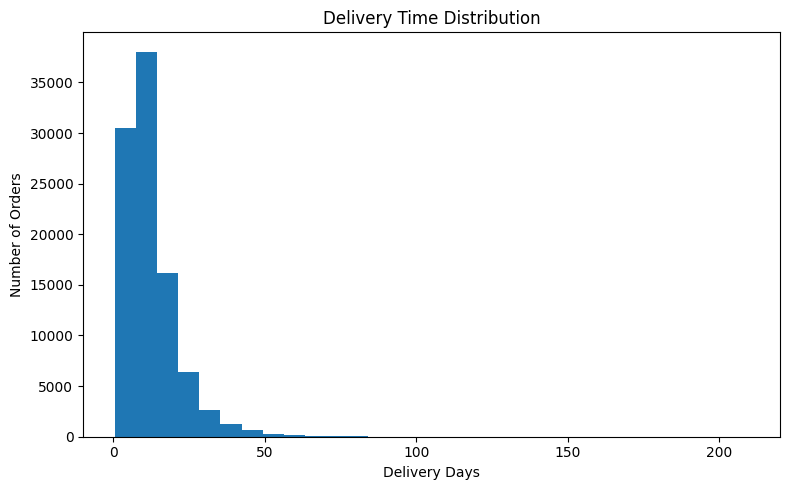

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(
    orders["delivery_days"].dropna(),
    bins=30
)
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.title("Delivery Time Distribution")
plt.tight_layout()
plt.show()

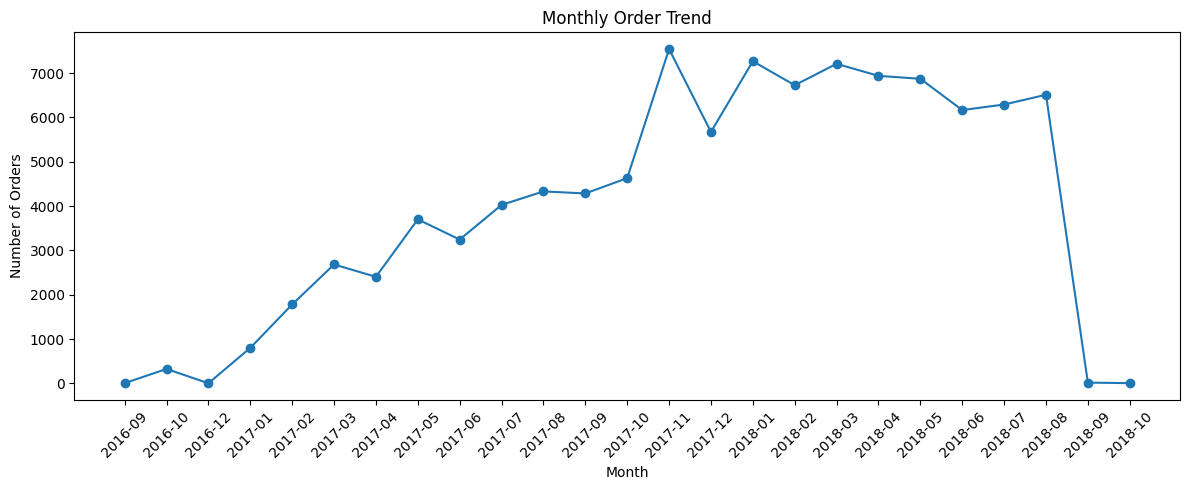

In [9]:
monthly_orders = (
    orders.groupby("order_month")
    .size()
    .reset_index(name="order_count")
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_orders["order_month"],
    monthly_orders["order_count"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

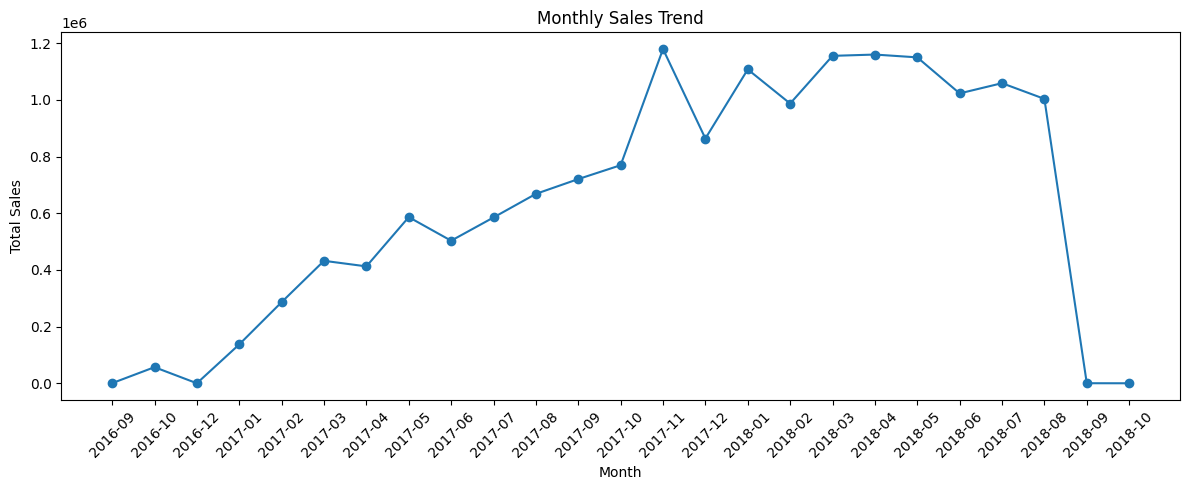

In [10]:
monthly_sales = (
    orders.groupby("order_month")["total_order_value"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["order_month"],
    monthly_sales["total_order_value"],
    marker="o"
)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
payment_summary = (
    pd.read_csv("engineered/orders_engineered.csv")
    .merge(
        pd.read_csv("engineered/order_items_engineered.csv")
        .groupby("order_id")["price"]
        .sum()
        .reset_index(name="order_price"),
        on="order_id",
        how="left"
    )
)

payments = pd.read_csv(
    "engineered_data.zip",
    compression="zip"
) if False else None

In [ ]:
payment_data = pd.read_csv("../data/cleaned/payments.csv", engine="python")

payment_summary = (
    payment_data.groupby("payment_type")
    .agg(
        payment_count=("order_id", "count"),
        total_payment_value=("payment_value", "sum")
    )
    .reset_index()
    .sort_values("total_payment_value", ascending=False)
)

payment_summary

,payment_type,payment_count,total_payment_value
1,credit_card,76795,12542084.19
0,boleto,19784,2869361.27
4,voucher,5775,379436.87
2,debit_card,1529,217989.79
3,not_defined,3,0.00


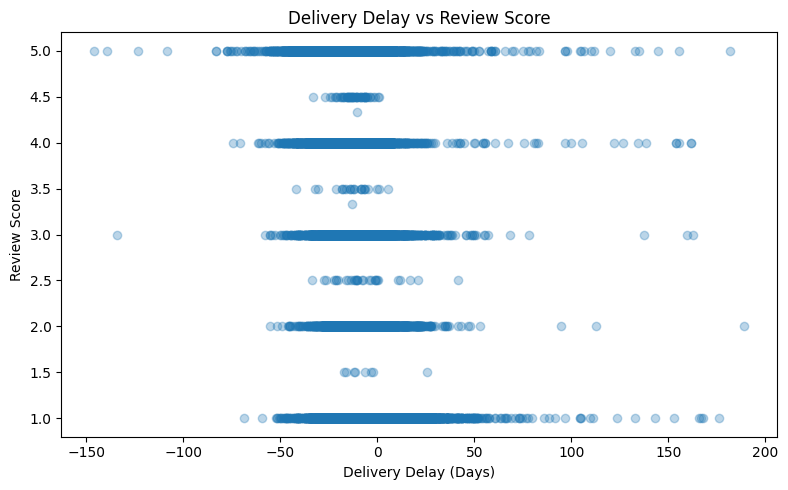

In [15]:
delivery_review = orders[
    ["delivery_delay_days", "review_score"]
].dropna()

plt.figure(figsize=(8, 5))
plt.scatter(
    delivery_review["delivery_delay_days"],
    delivery_review["review_score"],
    alpha=0.3
)
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Review Score")
plt.title("Delivery Delay vs Review Score")
plt.tight_layout()
plt.show()